 # ☕ Coffee Sales Intelligence: Strategic Analytics & Forecasting 
**Author:** Juliana | **Role:** Tech Lead & Data Scientist  
**Status:** MVP - Version 1.0

---

## 🎯 Contexto e Visão de Liderança
Este projeto simula os dados em uma rede de cafeterias. O foco não é apenas a análise descritiva, mas a criação de uma **estrutura escalável de ETL** e um **modelo preditivo** focado em otimização de estoque e aumento de ticket médio.

### 🛠 Tech Stack & Governance
A escolha das ferramentas reflete um compromisso com performance, interatividade e facilidade de manutenção:

| Ferramenta | Função | Justificativa Estratégica |
| :--- | :--- | :--- |
| **Python 3.x** | Core Engine | Versatilidade para integração com APIs e automação. |
| **Pandas** | Data Manipulation | Eficiência no processamento de estruturas tabulares e ETL. |
| **Scikit-Learn** | Machine Learning | Framework padrão ouro para modelos de regressão e clustering. |
| **Plotly** | Data Viz | Gráficos interativos para stakeholders consumirem insights dinâmicos. |
| **Jupyter** | Storytelling | Ambiente para desenvolvimento iterativo e documentação narrativa. |

### 🧩 Arquitetura do Projeto
1. **Ingestão & Limpeza:** Padronização de tipos e sanitização de nulos.
2. **Feature Engineering:** Criação de variáveis temporais e sazonais.
3. **Análise Exploratória (EDA):** Identificação de gargalos e oportunidades de receita.
4. **Modelagem:** Aplicação de ML para previsão de demanda.

<h1><span style="color:red">Setup de Configurações Globais</span></h1>

In [22]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split

<h1><span style="color:red">Ingestão de dados</span></h1>

In [10]:
# 1. Ingestão de Dados
# Simulando o carregamento do dataset do Kaggle
df = pd.read_csv('Coffe_sales.csv')



<h1><span style="color:red">Diagnóstico de integridade</span></h1>

In [11]:
# 2. Diagnóstico de Integridade (df.info)
# Este comando é crucial para identificar se tipos de dados (como datas) 
# foram carregados como strings, o que impediria análises temporais.
print("--- Diagnóstico de Tipos e Integridade ---")
df.info()


--- Diagnóstico de Tipos e Integridade ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


<h1><span style="color:red">Limpeza e transformação</span></h1>

<h3><span style="color:blue">Transformação: Ajuste de Tipagem e Datas</span></h3>

In [14]:
# Timestamp completo para permitir análises de séries temporais precisas
# O parâmetro format='mixed' resolve a inconsistência de milissegundos
df['full_timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='mixed')
df['Date'] = pd.to_datetime(df['Date'], format='mixed')


<h3><span style="color:blue">Engenharia de Atributos (Feature Engineering)</span></h3>

In [15]:
#Criando métricas de negócio para análise de comportamento
df['is_weekend'] = df['Weekdaysort'].apply(lambda x: 1 if x in [6, 7] else 0)

In [18]:
# Definindo períodos do dia mais granulares para a cafeteria
def categorize_detailed_time(hour):
    if 6 <= hour < 10: return 'Early Morning'
    if 10 <= hour < 14: return 'Lunch Peak'
    if 14 <= hour < 18: return 'Afternoon Tea'
    else: return 'Evening/Night'

df['detailed_period'] = df['hour_of_day'].apply(categorize_detailed_time)

<h3><span style="color:blue">Limpeza e Governança</span></h3>

In [19]:
# Remoção de colunas redundantes que já extraímos ou que não variam
cols_to_drop = ['cash_type', 'Time', 'Weekdaysort', 'Monthsort']
df_clean = df.drop(columns=cols_to_drop)

<h3><span style="color:blue">Visualização do Resultado do ETL</span></h3>

In [20]:
print("--- Check de Sanidade do ETL ---")
display(df_clean.head())
df_clean.info()

--- Check de Sanidade do ETL ---


,hour_of_day,money,coffee_name,Time_of_Day,Weekday,Month_name,Date,full_timestamp,is_weekend,detailed_period
0,10,38.7,Latte,Morning,Fri,Mar,2024-03-01,2024-03-01 10:15:50.520,0,Lunch Peak
1,12,38.7,Hot Chocolate,Afternoon,Fri,Mar,2024-03-01,2024-03-01 12:19:22.539,0,Lunch Peak
2,12,38.7,Hot Chocolate,Afternoon,Fri,Mar,2024-03-01,2024-03-01 12:20:18.089,0,Lunch Peak
3,13,28.9,Americano,Afternoon,Fri,Mar,2024-03-01,2024-03-01 13:46:33.006,0,Lunch Peak
4,13,38.7,Latte,Afternoon,Fri,Mar,2024-03-01,2024-03-01 13:48:14.626,0,Lunch Peak


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   hour_of_day      3547 non-null   int64         
 1   money            3547 non-null   float64       
 2   coffee_name      3547 non-null   object        
 3   Time_of_Day      3547 non-null   object        
 4   Weekday          3547 non-null   object        
 5   Month_name       3547 non-null   object        
 6   Date             3547 non-null   datetime64[ns]
 7   full_timestamp   3547 non-null   datetime64[ns]
 8   is_weekend       3547 non-null   int64         
 9   detailed_period  3547 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 277.2+ KB


<h1><span style="color:red">DASHBOARD</span></h1>

In [23]:
# Agrupamento de Dados para as Visualizações
daily_sales = df_clean.groupby('Date')['money'].sum().reset_index()
product_performance = df_clean.groupby('coffee_name')['money'].sum().sort_values(ascending=True).reset_index()
period_sales = df_clean.groupby('detailed_period')['money'].sum().reset_index()

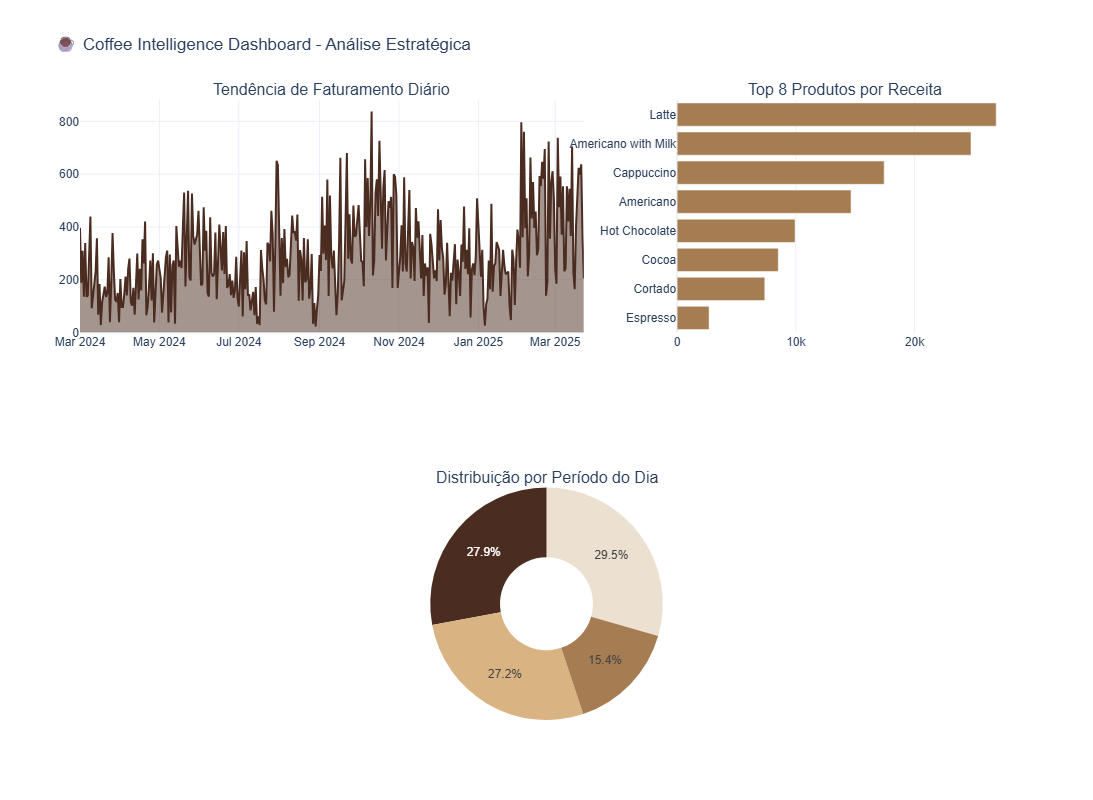

In [25]:
#Criando o Layout do Dashboard (Subplots)
fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.6, 0.4],
    row_heights=[0.5, 0.5],
    specs=[[{"type": "scatter"}, {"type": "bar"}],
           [{"type": "pie", "colspan": 2}, None]],
    subplot_titles=("Tendência de Faturamento Diário", "Top 8 Produtos por Receita", "Distribuição por Período do Dia")
)

# Gráfico 1: Série Temporal (Linha)
fig.add_trace(
    go.Scatter(x=daily_sales['Date'], y=daily_sales['money'], name="Receita Diária",
               line=dict(color='#4b2c20', width=2), fill='tozeroy'),
    row=1, col=1
)

# Gráfico 2: Performance de Produtos (Barras Horizontais)
fig.add_trace(
    go.Bar(x=product_performance['money'], y=product_performance['coffee_name'], 
           orientation='h', marker_color='#a67c52', name="Produtos"),
    row=1, col=2
)

# Gráfico 3: Distribuição por Período (Pizza/Donut)
fig.add_trace(
    go.Pie(labels=period_sales['detailed_period'], values=period_sales['money'], 
           hole=.4, marker=dict(colors=['#4b2c20', '#a67c52', '#d9b382', '#ece0d1'])),
    row=2, col=1
)

# 3. Estilização de Liderança (Layout Final)
fig.update_layout(
    title_text="☕ Coffee Intelligence Dashboard - Análise Estratégica",
    height=800,
    showlegend=False,
    template="plotly_white",
    font=dict(family="Arial", size=12)
)

fig.show()

<h1><span style="color:red">MACHINE LEARNING</span></h1>

In [ ]:
#prever o faturamento das próximas vendas com base no horário e tipo de café

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Preparação dos Dados (Preprocessing)
# Precisamos transformar categorias (texto) em números para o modelo
df_ml = df_clean.copy()
le = LabelEncoder()

categorical_cols = ['coffee_name', 'detailed_period', 'Weekday', 'Month_name']
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# 2. Definição de Features (X) e Target (y)
# Queremos prever 'money' com base no café, horário, dia e mês
X = df_ml[['hour_of_day', 'coffee_name', 'detailed_period', 'is_weekend', 'Month_name']]
y = df_ml['money']

# 3. Divisão Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinamento do Modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Avaliação de Performance
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Performance do Modelo ---")
print(f"Erro Médio Absoluto (MAE): ${mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

# 6. Importância das Variáveis 
importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
display(importances)

--- Performance do Modelo ---
Erro Médio Absoluto (MAE): $0.30
Coeficiente de Determinação (R²): 0.98


,feature,importance
1,coffee_name,0.876724
4,Month_name,0.110777
0,hour_of_day,0.009021
3,is_weekend,0.001914
2,detailed_period,0.001564
